In [1]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.providers.aer import QasmSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector

In [2]:
# Use Aer's qasm_simulator
simulator = QasmSimulator()

# Create a Quantum Circuit acting on the q register
circuit = QuantumCircuit(2, 2)

# Add a H gate on qubit 0
circuit.h(0)

# Add a CX (CNOT) gate on control qubit 0 and target qubit 1
circuit.cx(0, 1)

# Map the quantum measurement to the classical bits
circuit.measure([0,1], [0,1])

# compile the circuit down to low-level QASM instructions
# supported by the backend (not needed for simple circuits)
compiled_circuit = transpile(circuit, simulator)

# Execute the circuit on the qasm simulator
job = simulator.run(compiled_circuit, shots=1000)

# Grab results from the job
result = job.result()

# Returns counts
counts = result.get_counts(compiled_circuit)
print("\nTotal count for 00 and 11 are:",counts)

# Draw the circuit
circuit.draw()


Total count for 00 and 11 are: {'11': 500, '00': 500}


┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1

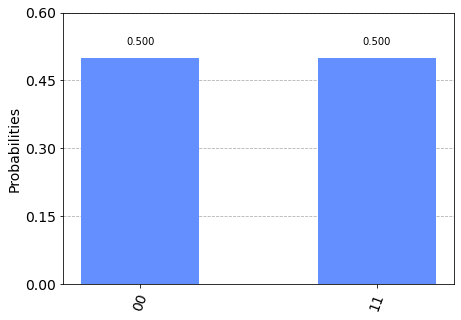

In [3]:
# Plot a histogram
plot_histogram(counts)

In [4]:
circuit2 = QuantumCircuit(1, 1)
circuit2.measure([0], [0])
circuit2.draw()

┌─┐
q_0: ┤M├
     └╥┘
c: 1/═╩═
      0

In [5]:
compiled_circuit = transpile(circuit2, simulator)
job = simulator.run(compiled_circuit, shots=1000)
result = job.result()
counts = result.get_counts(compiled_circuit)
print("\nTotal counts are:",counts)


Total counts are: {'0': 1000}


In [6]:
circuit2 = QuantumCircuit(1, 1)
circuit2.i(0)
circuit2.measure([0], [0])
circuit2.draw()


┌───┐┌─┐
q_0: ┤ I ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0

In [7]:
compiled_circuit = transpile(circuit2, simulator)
job = simulator.run(compiled_circuit, shots=1000)
result = job.result()
counts = result.get_counts(compiled_circuit)
print("\nTotal counts are:",counts)


Total counts are: {'0': 1000}


In [8]:
circuit2 = QuantumCircuit(1, 1)
circuit2.x(0)
circuit2.measure([0], [0])
circuit2.draw()

┌───┐┌─┐
q_0: ┤ X ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0

In [9]:
compiled_circuit = transpile(circuit2, simulator)
job = simulator.run(compiled_circuit, shots=1000)
result = job.result()
counts = result.get_counts(compiled_circuit)
print("\nTotal counts are:",counts)


Total counts are: {'1': 1000}


In [10]:
# circuit with depth 1 and width 3
circuit2 = QuantumCircuit(3, 3)
circuit2.x(1)
circuit2.measure([0,1,2], [0,1,2])
circuit2.draw()

┌─┐   
q_0: ─────┤M├───
     ┌───┐└╥┘┌─┐
q_1: ┤ X ├─╫─┤M├
     └┬─┬┘ ║ └╥┘
q_2: ─┤M├──╫──╫─
      └╥┘  ║  ║ 
c: 3/══╩═══╩══╩═
       2   0  1

In [11]:
compiled_circuit = transpile(circuit2, simulator)
job = simulator.run(compiled_circuit, shots=1000)
result = job.result()
counts = result.get_counts(compiled_circuit)
print("\nTotal counts are:",counts)


Total counts are: {'010': 1000}


In [12]:
# Circuit with depth 1 and width 1
circuit2 = QuantumCircuit(1, 1)
circuit2.h(0)
circuit2.measure([0], [0])
circuit2.draw()

┌───┐┌─┐
q_0: ┤ H ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0

In [13]:
compiled_circuit = transpile(circuit2, simulator)
job = simulator.run(compiled_circuit, shots=200000)
result = job.result()
counts = result.get_counts(compiled_circuit)
print("\nTotal counts are:",counts)


Total counts are: {'1': 99727, '0': 100273}


In [14]:
c = QuantumCircuit(1, 1)
c.h(0)
c.h(0)
c.measure([0], [0])
c.draw()

┌───┐┌───┐┌─┐
q_0: ┤ H ├┤ H ├┤M├
     └───┘└───┘└╥┘
c: 1/═══════════╩═
                0

In [15]:
compiled_circuit = transpile(c, simulator)
job = simulator.run(compiled_circuit, shots=1000)
result = job.result()
counts = result.get_counts(compiled_circuit)
print("\nTotal counts are:",counts)


Total counts are: {'0': 1000}


In [16]:
c = QuantumCircuit(1, 2)
c.h(0)
c.measure([0],[0])
c.h(0)
c.measure([0], [1])
c.draw()

┌───┐┌─┐┌───┐┌─┐
q_0: ┤ H ├┤M├┤ H ├┤M├
     └───┘└╥┘└───┘└╥┘
c: 2/══════╩═══════╩═
           0       1

In [17]:
# Why didn't the two H gates cancel each other out?!!!
compiled_circuit = transpile(c, simulator)
job = simulator.run(compiled_circuit, shots=1000)
result = job.result()
counts = result.get_counts(compiled_circuit)
print("\nTotal counts are:",counts)


Total counts are: {'00': 272, '10': 282, '01': 214, '11': 232}


In [18]:
c = QuantumCircuit(2, 2)
c.h(0)
c.cx(0,1)
c.measure([0,1], [0,1])
c.draw()

┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1

In [19]:
# Why only 00 and 11?
compiled_circuit = transpile(c, simulator)
job = simulator.run(compiled_circuit, shots=1000)
result = job.result()
counts = result.get_counts(compiled_circuit)
print("\nTotal counts are:",counts)


Total counts are: {'11': 492, '00': 508}


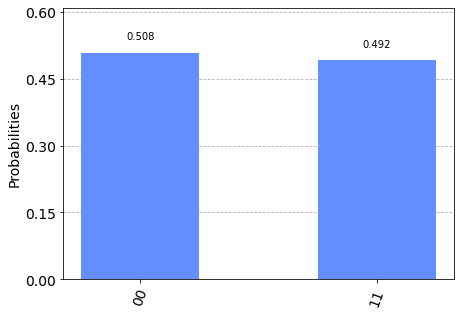

In [20]:
plot_histogram(counts)

In [21]:
#Quantum adder add all possible pairs at once
c = QuantumCircuit(3,3)
c.h(0)
c.h(1)
c.cx(0,2) # set the start bits to 0 and 1
c.x(1)
c.cx(1,2)
c.measure([2],[2])
c.measure([0],[0])
c.measure([1],[1])
c.draw()

┌───┐               ┌─┐      
q_0: ┤ H ├──■────────────┤M├──────
     ├───┤  │  ┌───┐     └╥┘   ┌─┐
q_1: ┤ H ├──┼──┤ X ├──■───╫────┤M├
     └───┘┌─┴─┐└───┘┌─┴─┐ ║ ┌─┐└╥┘
q_2: ─────┤ X ├─────┤ X ├─╫─┤M├─╫─
          └───┘     └───┘ ║ └╥┘ ║ 
c: 3/═════════════════════╩══╩══╩═
                          0  2  1

In [22]:
compiled_circuit = transpile(c, simulator)
job = simulator.run(compiled_circuit, shots=1000)
result = job.result()
counts = result.get_counts(compiled_circuit)
print("\nTotal counts are:",counts)


Total counts are: {'101': 244, '110': 271, '000': 241, '011': 244}


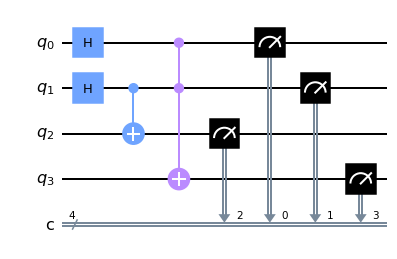

In [23]:
#Quantum adder add all possible pairs at once
c = QuantumCircuit(4,4)
c.h(0)
c.h(1)
c.cx(1,2)
c.ccx(0,1,3)
c.measure([2],[2])
c.measure([0],[0])
c.measure([1],[1])
c.measure([3],[3])
c.draw('mpl')

In [24]:
circ = transpile(c, simulator)
job = simulator.run(circ, shots=1000)
result = job.result()
counts = result.get_counts(circ)
print("\nTotal counts are:",counts)


Total counts are: {'0001': 243, '0000': 252, '0110': 263, '1111': 242}


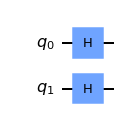

In [25]:
c = QuantumCircuit(2)
c.h(0)
c.h(1)
c.draw('mpl')

In [26]:
from qiskit.quantum_info import Statevector
# Set the intial state of the simulator to the ground state using from_int
state = Statevector.from_int(0, 2**2)

# Evolve the state by the quantum circuit
state = state.evolve(c)

#draw using latex
state.draw('latex')


<IPython.core.display.Latex object>

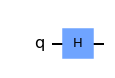

In [27]:
c = QuantumCircuit(1)
#c.u(pi/3, pi/6, 0, 0)
c.h(0)
c.draw('mpl')

In [28]:
from qiskit.quantum_info import Statevector
# Set the intial state of the simulator to the ground state using from_int
state = Statevector.from_int(0, 2)

# Evolve the state by the quantum circuit
state = state.evolve(c)

#draw using latex
state.draw('latex')




<IPython.core.display.Latex object>

In [29]:
from qiskit.visualization import plot_bloch_vector

In [30]:
from qiskit.quantum_info import Operator

U = Operator(c)

# Show the results
U.data

array([[ 0.70710678+0.j,  0.70710678+0.j],
       [ 0.70710678+0.j, -0.70710678+0.j]])

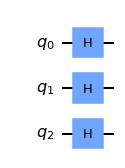

In [31]:
#example of H3
c = QuantumCircuit(3)
c.h(0)
c.h(1)
c.h(2)
c.draw('mpl')

In [32]:
state = Statevector.from_int(0, 2**3)
state = state.evolve(c)
state.draw('latex')

<IPython.core.display.Latex object>